<a href="https://colab.research.google.com/github/Dharshini13002/Machine-learning-codes/blob/main/SEM_AML_7010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Multiple Linear Regression With Cross Tabulation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [ ]:
# -----------------------------
# Step 1: Load Dataset
# -----------------------------
# If using Colab, first upload qp2.xlsx
# from google.colab import files
# files.upload()

data = pd.read_excel("/content/drive/MyDrive/qp8 (1).xlsx")
print("Dataset Preview:\n", data.head())

Dataset Preview:
   Payment method Coupon Applied Product Category Region  Price (Rs.)  Units  \
0                           Yes               P2   East        19.95      2   
1    Master card            Yes               P3   West        22.95      1   
2    Master card             No               P4   East        19.95      1   
3    Master card             No               P1  North        22.95      5   
4           Visa             No               P1   West        22.95      1   

    Sales          
0   39.90     NaN  
1   22.95     NaN  
2   19.95          
3  114.75     NaN  
4   22.95     NaN  


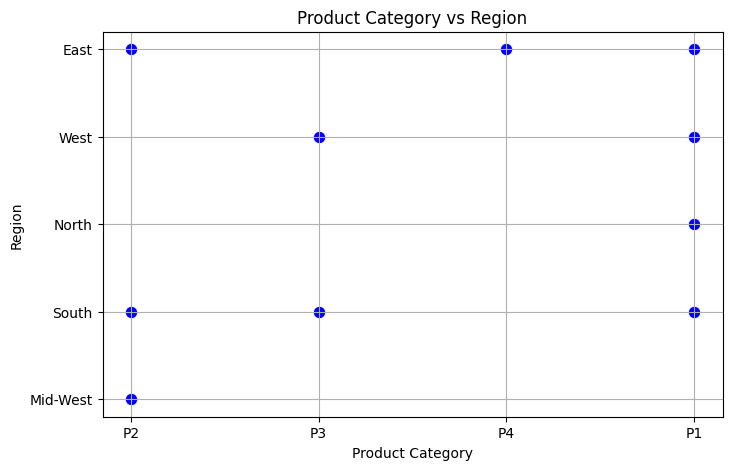

In [ ]:
# -----------------------------
# Step 2: Data Visualization
# -----------------------------
plt.figure(figsize=(8,5))
sns.scatterplot(x='Product Category', y='Region', data=data, color='blue', s=80)
plt.title('Product Category vs Region') # Title might need adjustment based on actual data
plt.xlabel('Product Category') # Label might need adjustment
plt.ylabel('Region')
plt.grid(True)
plt.show()


In [ ]:
# -----------------------------
# Step 3: Feature and Target
# -----------------------------
X = data[['Product Category','Region','Sales']]  # independent variable
y = data['Sales']           # dependent variable (Assuming 'Sales' is the target based on available columns)

# Convert categorical features to dummy variables
X = pd.get_dummies(X, columns=['Product Category', 'Region'], drop_first=True)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# -----------------------------
# Step 4: Train Linear Regression Model
# -----------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# Coefficients
print("\nIntercept (β₀):", model.intercept_)
# Print coefficients for all features
print("Coefficients:", model.coef_)


Intercept (β₀): 1.4210854715202004e-14
Coefficients: [ 1.00000000e+00  9.24685030e-15 -1.92671955e-18  4.84836996e-16
  9.24685030e-15  5.76602916e-15  2.14707921e-16  2.18789817e-16]


In [ ]:
# -----------------------------
# Step 5: Predictions
# -----------------------------
y_pred = model.predict(X_test)

In [ ]:
# -----------------------------
# Step 6: Model Evaluation
# -----------------------------
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nModel Performance:")
print("R² Score:", round(r2, 4))
print("Root Mean Square Error:", round(rmse, 4))


Model Performance:
R² Score: 1.0
Root Mean Square Error: 0.0


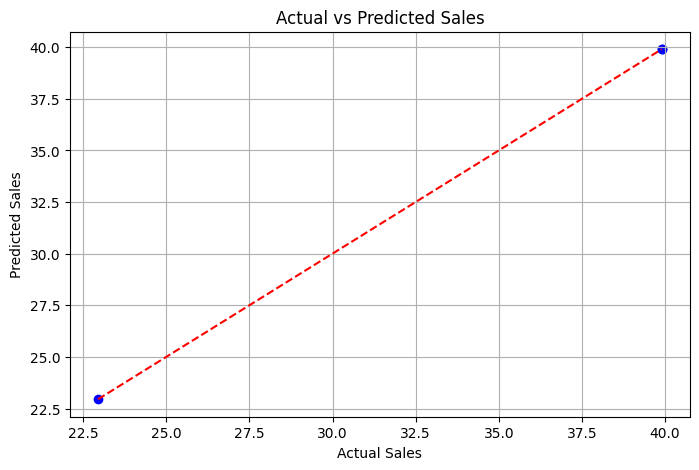

In [ ]:

# -----------------------------
# Step 7: Predicted vs Actual Sales Plot
# -----------------------------
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--') # Add a diagonal line for reference
plt.title('Actual vs Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.grid(True)
plt.show()


In [ ]:
# -----------------------------
# PART B: Cross Tabulation (qp8.xlsx)
# -----------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data_qp8 = pd.read_excel("/content/drive/MyDrive/AML datasets/qp8.xlsx")
print("Dataset Preview:\n", data_qp8.head())



Dataset Preview:
   Payment method Coupon Applied Product Category Region  Price (Rs.)  Units  \
0    Master card            Yes               P2   East        19.95      2   
1    Master card            Yes               P3   West        22.95      1   
2    Master card             No               P4   East        19.95      1   
3    Master card             No               P1  North        22.95      5   
4           Visa             No               P1   West        22.95      1   

    Sales  
0   39.90  
1   22.95  
2   19.95  
3  114.75  
4   22.95  


In [ ]:
# Example columns:
# Payment Method | Coupon Applied | Product Category | Region | Price (Rs.) | Units | Sales

# Create Cross Tabulations
# 1️⃣ Average Sales per Region & Product Category
sales_region_product = pd.crosstab(index=data_qp8['Region'],
                                   columns=data_qp8['Product Category'],
                                   values=data_qp8['Sales'],
                                   aggfunc='mean').round(2)
print("\nAverage Sales by Region & Product Category:\n", sales_region_product)


Average Sales by Region & Product Category:
 Product Category      P1     P2     P3     P4
Region                                       
East               59.85  39.90    NaN  19.95
Mid-West             NaN  29.92    NaN    NaN
North             114.75    NaN    NaN    NaN
South              34.42  22.95  45.90    NaN
West               22.95    NaN  22.95    NaN


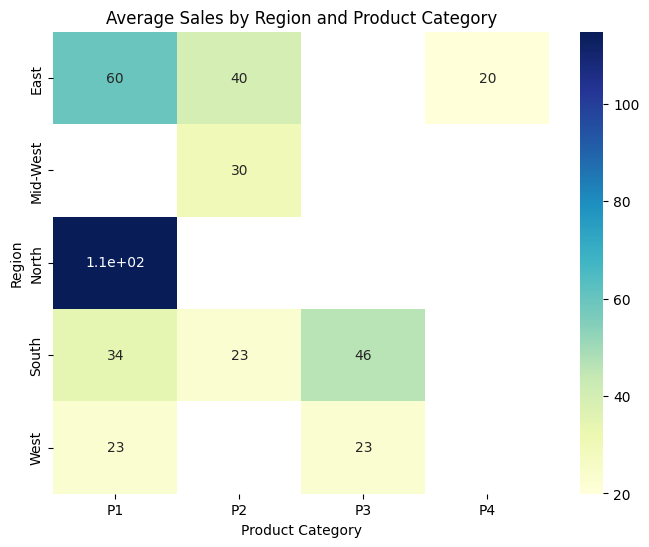

In [ ]:
# 3️⃣ Visualize using Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(sales_region_product, annot=True, cmap='YlGnBu')
plt.title('Average Sales by Region and Product Category')
plt.show()



In [ ]:
# 2️⃣ Total Sales by Payment Method and Coupon Usage
sales_payment_coupon = pd.crosstab(index=data_qp8['Payment method'],
                                   columns=data_qp8['Coupon Applied'],
                                   values=data_qp8['Sales'],
                                   aggfunc='sum').fillna(0)
print("\nTotal Sales by Payment Method and Coupon:\n", sales_payment_coupon)


Total Sales by Payment Method and Coupon:
 Coupon Applied        No    Yes
Payment method                 
American Express    0.00  42.90
Master card       134.70  62.85
Paypal             68.85  45.90
Visa               82.80  39.90


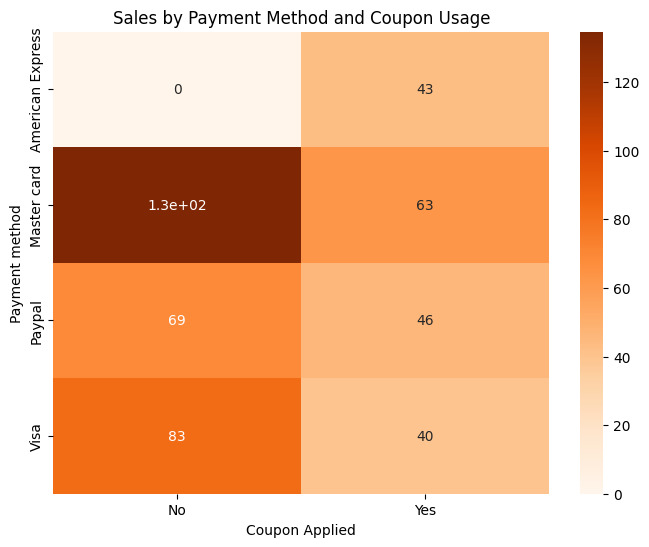

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(sales_payment_coupon, annot=True, cmap='Oranges')
plt.title('Sales by Payment Method and Coupon Usage')
plt.show()